<a href="https://colab.research.google.com/github/databydenise/Data-Science-Tech-Scholarship/blob/main/session_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mentor - Denise Moemeke

In [2]:
from google.colab import drive
drive.mount('/content/drive',  force_remount=True)

Mounted at /content/drive


# Lesson 3 — Statistics That Actually Matter

## From finding patterns to reasoning about data

In the previous lesson, we used Pandas to explore data:

- filtering rows
- selecting columns
- sorting values
- grouping data
- calculating aggregates
- identifying patterns and findings

But pattern recogition is just a start.

In this lesson, we will learn how to ask:

> **What does this pattern actually tell us?**

We will focus on statistical intuition rather than memorising formulas.

By the end of this lesson, you should be able to:

- describe the distribution of a variable
- understand mean, median and quartiles
- identify outliers
- understand variance and standard deviation as measures of spread
- distinguish correlation from causation
- understand the purpose of sampling
- understand the basic logic of hypothesis testing
- recognise common ways statistics can be misleading
- choose an appropriate statistical approach for a real question

## 1. The answer is more than a number

Imagine that we analyse Olist and discover:

> The average product price is R$120.

What does that tell us?

It tells us the mean price.

But does it tell us what a **typical** product costs?

Not necessarily.

Before interpreting a statistic, we need to understand the data behind it.

For example:

- Are most products close to R$120?
- Are there a few extremely expensive products?
- Is the distribution symmetric or skewed?
- What is the median?
- How spread out are the prices?
- Are there unusual observations?

This is why statistics is more than calculating a number.

> **The goal is to understand the shape, centre and spread of the data before drawing conclusions from it.**

## Unbalanced Data

In the **Olist context**, a very intuitive example would be **order status**.

Suppose you wanted to predict whether an order will be **delivered** or **not delivered**.

In the Olist data, there are roughly **96,000 delivered orders out of about 99,000 total orders**. That means the classes are extremely uneven:

| Outcome       | Approx. orders | Proportion |
| ------------- | -------------: | ---------: |
| Delivered     |         96,478 |       ~97% |
| Not delivered |         ~2,963 |        ~3% |

So if you built a model that simply predicted:

> **"Delivered" for every single order**

it would be about **97% accurate**.

But the model would be completely useless for identifying the orders that *aren't* delivered.

### That's imbalanced data.

The important intuition is:

> **A high accuracy score can be misleading when one class massively outnumbers the other.**


```python
orders["order_status"].value_counts(normalize=True)
```

> Imagine a model that achieves 97% accuracy.
>
> Sounds amazing, right?
>
> Now imagine it predicts **"delivered" every time**.
>
> It gets almost every observation right because almost every observation is delivered.
>
> But it has learned nothing useful about the minority class.

That's why, with imbalanced data, we might care about metrics such as **precision, recall, F1-score, or the confusion matrix**, rather than accuracy alone.

Again,

> **The statistic isn't necessarily wrong. The problem is using a statistic that hides the thing we actually care about.**


In [3]:
import os #allows Python code to interact with the underlying operating system (Linux)
# of the Colab virtual machine. filed directories and existence
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [4]:
dataset_path = '/content/drive/MyDrive/Tech Scholarship Data Science Curriculum & Materials/notebooks-&-dataset/dataset'

In [5]:
print(os.listdir(dataset_path))

['olist_customers_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_sellers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_products_dataset.csv', 'olist_order_items_dataset.csv', 'product_category_name_translation.csv']


In [6]:
orders = pd.read_csv(os.path.join(dataset_path, "olist_orders_dataset.csv"))
order_items = pd.read_csv(os.path.join(dataset_path, "olist_order_items_dataset.csv"))

In [7]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


# 2. Revisiting the Previous Lesson

Before moving forward, let's check our answers from the previous assignment.



### Question 1: How many orders are in the dataset?

We can count the rows in the `orders` DataFrame.

In [9]:
orders.shape

(99441, 8)

In [10]:
len(orders)

99441

### Question 2: What are the available order statuses?

The `order_status` column contains categorical information about the current state of an order.

We can use `unique()` to see the categories that occur in the dataset.

In [11]:
orders["order_status"].unique()

array(['delivered', 'invoiced', 'shipped', 'processing', 'unavailable',
       'canceled', 'created', 'approved'], dtype=object)

### Question 3 — Number of orders per status

In [12]:
orders["order_status"].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


The vast majority of orders have the status `delivered`.

However, notice that simply knowing the most common category does not tell us everything about the dataset.

For example, it does not tell us:

- how long delivery took
- how much products cost
- whether some sellers perform differently
- whether delivery performance varies across orders

Statistics becomes useful when we move beyond counting categories and start investigating the variation within the data.

### Question 4 — Most common status

In [14]:
orders["order_status"].value_counts().idxmax()

'delivered'

## Filtering: Delivered Orders

The previous assignment asked us to create a DataFrame containing only delivered orders.

In [15]:
delivered_orders = orders[
    orders["order_status"] == "delivered"
]

delivered_orders.shape

(96478, 8)

In [16]:
delivered_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [17]:
len(delivered_orders)

96478

In [ ]:
delivered_orders.head()

### Q5. Previous seller analysis

# Seller Analysis — Answer

Using `order_items`, we can calculate:

1. total sales per seller
2. average item price per seller
3. number of items per seller
4. the sellers with the highest total sales

In [18]:
seller_analysis = (
    order_items
    .groupby("seller_id")
    .agg(
        total_sales=("price", "sum"),
        average_price=("price", "mean"),
        number_of_items=("order_id", "count")
    )
    .sort_values("total_sales", ascending=False)
)

seller_analysis.head(10)

,total_sales,average_price,number_of_items
seller_id,,,
4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,198.505735,1156
53243585a1d6dc2643021fd1853d8905,222776.05,543.356220,410
4a3ca9315b744ce9f8e9374361493884,200472.92,100.892260,1987
fa1c13f2614d7b5c4749cbc52fecda94,194042.03,331.129744,586
7c67e1448b00f6e969d365cea6b010ab,187923.89,137.774113,1364
7e93a43ef30c4f03f38b393420bc753a,176431.87,518.917265,340
da8622b14eb17ae2831f4ac5b9dab84a,160236.57,103.311779,1551
7a67c85e85bb2ce8582c35f2203ad736,141745.53,121.046567,1171
1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,97.316912,1428


## BACK 2 CLASS
## DISTRIBUTIONS

# 3. Understanding Distributions

A distribution describes how the values of a variable are spread across observations.

Instead of asking only:

> "What is the average price?"

we can ask:

> "How are prices distributed?"

When looking at a distribution, we should pay attention to:

- **centre** — where the values tend to be concentrated
- **spread** — how much the values vary
- **shape** — whether the distribution is symmetric, skewed, clustered, etc.
- **outliers** — unusually large or small observations
- **quartiles** — points that divide the ordered data into four parts

In [19]:
order_items["price"].describe()

,price
count,112650.000000
mean,120.653739
std,183.633928
min,0.850000
25%,39.900000
50%,74.990000
75%,134.900000
max,6735.000000


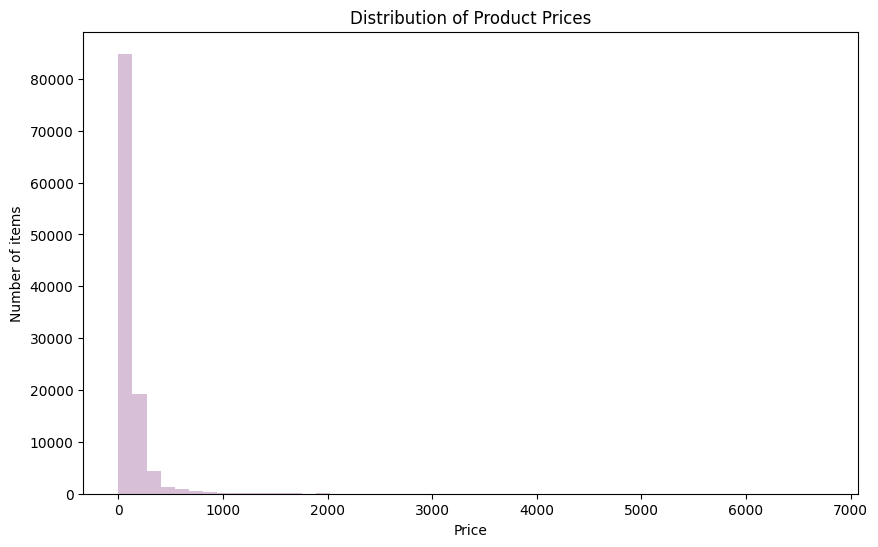

In [20]:
plt.figure(figsize=(10, 6))

plt.hist(order_items["price"], bins=50, color='thistle')

plt.xlabel("Price")
plt.ylabel("Number of items")
plt.title("Distribution of Product Prices")

plt.show()

### What do you notice?

Look at the shape of the distribution.

Ask:

1. Where are most observations concentrated?
2. Is the distribution symmetric?
3. Is there a long tail?
4. Are there unusually expensive products?
5. Would the mean or median better represent a "typical" product?

## Mean vs Median

The **mean** is calculated by adding all values and dividing by the number of observations.

The **median** is the middle value after the observations have been ordered.

These two measures can be very different when a distribution contains extreme values.

For example:

> 10, 10, 10, 10, 1000

The mean is strongly affected by the 1000.

The median is still 10.

This is why we should look at the distribution before deciding which measure best represents the centre.

In [21]:
mean_price = order_items["price"].mean()
median_price = order_items["price"].median()

print("Mean:", mean_price)
print("Median:", median_price)

Mean: 120.65373901464716
Median: 74.99


### What does the difference tell us?

If the mean is substantially higher than the median, that is evidence that some relatively large values are pulling the mean upward.

This does **not** mean the mean is "wrong".

It means that the mean and median answer slightly different questions.

The mean uses every observation and is sensitive to extreme values.

The median is much more resistant to extreme observations.

Therefore, when a distribution is strongly skewed, the median can sometimes give a better sense of the typical observation.

In [22]:
order_items["price"].quantile([0.25, 0.50, 0.75])

,price
0.25,39.90
0.50,74.99
0.75,134.90


In [23]:
Q1 = order_items["price"].quantile(0.25)
Q2 = order_items["price"].quantile(0.50)
Q3 = order_items["price"].quantile(0.75)

print("Q1:", Q1)
print("Median:", Q2)
print("Q3:", Q3)

Q1: 39.9
Median: 74.99
Q3: 134.9


## Interquartile Range (IQR)

The interquartile range measures the spread of the middle 50% of the data.

$$
IQR = Q3 - Q1
$$

The IQR is useful because it is less affected by extreme values than measures based on the mean.

### Detecting potential outliers

A commonly used rule defines potential outliers as observations:

- below `Q1 - 1.5 × IQR`
- above `Q3 + 1.5 × IQR`

Important:

> An observation identified as an outlier is not automatically an error.

It may be a perfectly valid observation that is simply unusual.

In [24]:
Q1 = order_items["price"].quantile(0.25)
Q3 = order_items["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

IQR: 95.0
Lower bound: -102.6
Upper bound: 277.4


In [25]:
outliers = order_items[
    (order_items["price"] < lower_bound) |
    (order_items["price"] > upper_bound)
]

outliers.shape

(8427, 7)

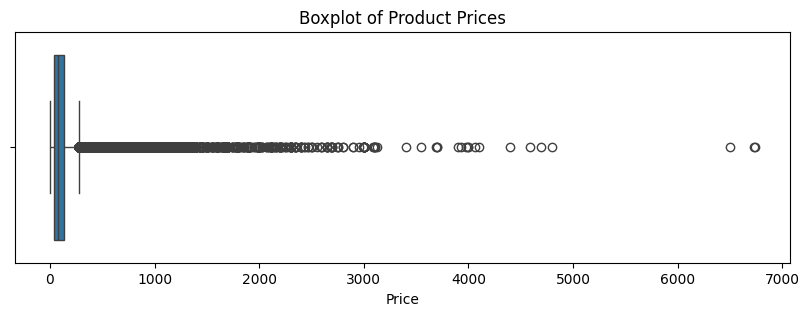

In [26]:
plt.figure(figsize=(10, 3))

sns.boxplot(x=order_items["price"])

plt.xlabel("Price")
plt.title("Boxplot of Product Prices")

plt.show()

## Reading a boxplot

A boxplot gives us a compact view of a distribution.

It shows:

- the median
- Q1
- Q3
- the interquartile range
- potential outliers

The box represents the middle 50% of observations.

The line inside the box represents the median.

Points beyond the whiskers are commonly treated as potential outliers under the 1.5 × IQR rule.

### Important

A boxplot does not tell us that every point outside the whiskers is a mistake.

It tells us that those observations are unusual relative to the rest of the distribution.

# 5. Measuring Spread

Knowing the centre of a distribution is not enough.

Consider two groups:

Group A:
> 48, 49, 50, 51, 52

Group B:
> 10, 30, 50, 70, 90

Both have a mean of 50.

But they clearly do not have the same amount of variation.

This is why we need measures of spread.

## Standard Deviation

Standard deviation is the square root of variance.

It is useful because it is expressed in the same units as the original variable.

For example, if price is measured in reais, the standard deviation is also measured in reais.

In [27]:
price_variance = order_items["price"].var()
price_std = order_items["price"].std()

print("Variance:", price_variance)
print("Standard deviation:", price_std)

Variance: 33721.41953116588
Standard deviation: 183.63392805025404


# 6. Guided Reasoning Exercise

Suppose we tell you:

> The average product price on Olist is R$120.

Would you consider this enough information to describe product prices?

### Think before running any code.

1. What additional information would you want?
2. Would you want the median?
3. Would you want Q1 and Q3?
4. Would you want to see a histogram?
5. Would you want to know whether there are outliers?
6. Would you want a measure of spread?

### Challenge

Write 2–3 sentences explaining why reporting only the mean can sometimes be misleading.

# 7. Correlation

So far, we have studied individual variables.

Now we can ask:

> **Are two numerical variables related?**

For example:

> Is product price related to freight cost?

We can investigate this using a scatterplot and correlation.

In [29]:
order_items[["price", "freight_value"]].corr()

,price,freight_value
price,1.000000,0.414204
freight_value,0.414204,1.000000


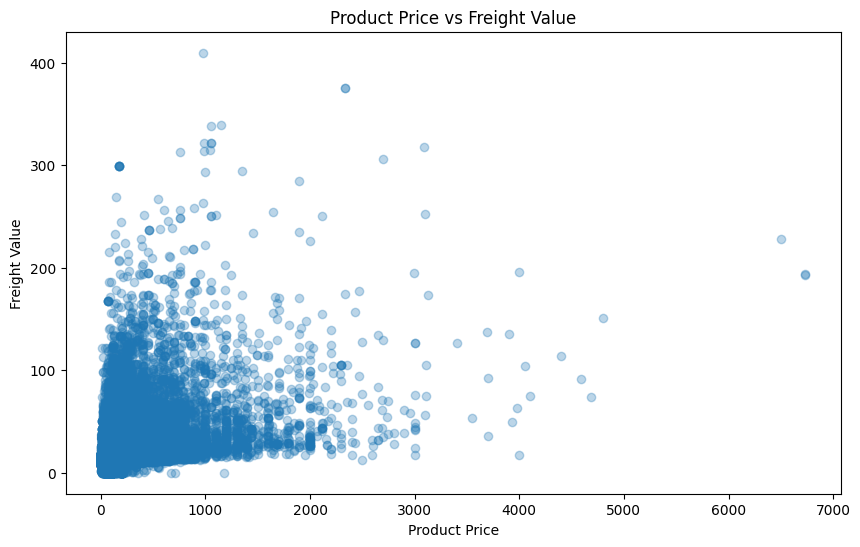

In [28]:
plt.figure(figsize=(10, 6))

plt.scatter(
    order_items["price"],
    order_items["freight_value"],
    alpha=0.3
)

plt.xlabel("Product Price")
plt.ylabel("Freight Value")
plt.title("Product Price vs Freight Value")

plt.show()

## Correlation does not imply causation

Suppose we find that price and freight value are positively correlated.

This means that higher product prices tend to be associated with higher freight values.

But it does **not** prove:

> "Increasing the product price causes the freight cost to increase."

There may be other explanations.

For example, more expensive products may also tend to:

- be larger
- be heavier
- require different packaging
- be sold by different types of sellers
- be shipped over different distances

These other variables may help explain the relationship.

### Remember:

> **Correlation describes a relationship. It does not automatically establish a cause-and-effect relationship.**

# 8. How Statistics Can Mislead Us

Statistics are powerful, but statistics can also be presented in misleading ways.

Here are some common problems.

### 1. Reporting only the mean

An average can hide skewness, variation and outliers.

### 2. Ignoring sample size

"90% of customers preferred Product A"

sounds impressive.

But was the survey based on 10 people or 100,000 people?

### 3. Cherry-picking

Looking only at the time period, group or observations that support a particular conclusion.

### 4. Correlation presented as causation

Two variables moving together does not prove that one causes the other.

### 5. Misleading visualisations

Changing an axis or scale can make a small difference look enormous.

### 6. Statistical significance vs practical significance

A result can be statistically significant while the actual difference is too small to matter in practice.

### 7. Treating outliers as errors automatically

An unusual observation may be a genuine observation.

Removing it without justification can change the conclusions of an analysis.

# 9. Sampling

Imagine that we want to know something about every order Olist has ever processed.

We could analyse the entire dataset.

But in many real-world situations, collecting data from an entire population may be expensive, slow or impossible.

Instead, we often work with a **sample**.

### Population

The full group we want to understand.

### Sample

A subset of that population that we actually observe.

The goal is for the sample to provide useful information about the population.

But there is a problem:

> Different samples can produce different results.

This is called **sampling variability**.

In [30]:
sample_1 = order_items["price"].sample(500, random_state=1)
sample_2 = order_items["price"].sample(500, random_state=2)

print("Sample 1 mean:", sample_1.mean())
print("Sample 2 mean:", sample_2.mean())

Sample 1 mean: 118.67052000000001
Sample 2 mean: 108.41744


### What happened?

Both samples came from the same dataset.

Yet their means are not necessarily identical.

This illustrates an important idea:

> **A sample statistic is an estimate, not a guarantee.**

If we repeatedly take samples, our estimates will vary.

# 10. Hypothesis Testing

Suppose we have a question:

> **Is there evidence that two groups have different average prices?**

We need a structured way to decide whether an observed difference could reasonably be explained by random variation.

This is the basic idea behind hypothesis testing.

### Null hypothesis

The null hypothesis represents the default assumption.

For example:

> There is no difference in the population means.

### Alternative hypothesis

The alternative represents the possibility we are investigating.

For example:

> The population means are different.

We then use the sample data to determine how compatible our observations are with the null hypothesis.

### The p-value

A p-value tells us how unusual our observed result would be **if the null hypothesis were true**.

A small p-value provides evidence against the null hypothesis.

But remember:

> **The p-value is NOT the probability that the null hypothesis is true.**

## Do we always need a statistical test?

No.

A statistical test should be chosen because it answers the question we are asking.

For our current dataset, we can meaningfully investigate the relationship between `price` and `freight_value` using correlation.

We should not invent an arbitrary grouping simply to apply a t-test.

> **Choosing not to perform a statistical test can itself be the correct statistical decision.**

In [31]:
correlation, p_value = pearsonr(
    order_items["price"],
    order_items["freight_value"]
)

print("Correlation:", correlation)
print("p-value:", p_value)

Correlation: 0.41420431036303496
p-value: 0.0


### Interpreting the result

The test gives us two pieces of information:

**Correlation coefficient**

This describes the direction and strength of the linear relationship.

**p-value**

This helps us assess whether the observed correlation is inconsistent with a population correlation of zero.

However:

> A statistically significant correlation does not necessarily mean the relationship is strong or practically important.

With a very large dataset, even a relatively small relationship can produce a very small p-value.

This is why we should consider both **statistical significance and effect size**.

# 11. Guided Statistical Investigation

Your turn :)

Choose a real question that can be investigated using the Olist data.

Before writing code, answer:

### Step 1 — What is your question?

Write one clear question.

### Step 2 — What variables do you need?

Identify the relevant columns.

### Step 3 — What type of variables are they?

Are they:

- numerical?
- categorical?
- datetime?

### Step 4 — What would you expect to see?

Write your expectation before analysing the data.

### Step 5 — What statistical approach is appropriate?

Consider:

- summary statistics
- distribution analysis
- comparison of groups
- correlation
- hypothesis testing

### Step 6 — What visualisation would help?

Choose an appropriate plot.

### Step 7 — What does the result tell you?

Explain the result in plain language.

### Step 8 — What can you NOT conclude?

Think about:

- causation
- sampling
- confounding variables
- outliers
- limitations of the data

# 12. Assignment — Statistical Reasoning with Olist

## Task

Choose **one real question** that can be investigated using the Olist dataset.

Your goal is not simply to calculate a statistic.

Your goal is to demonstrate statistical reasoning.

### Your notebook must include:

#### 1. Research Question

State a clear question that can be answered using the available data.

#### 2. Variables

Identify the variables you will use and explain what they represent.

#### 3. Exploratory Analysis

Use appropriate summary statistics and visualisations to understand your data.

Consider:

- distribution
- mean and median
- quartiles
- spread
- outliers

Use only the analyses that are relevant to your question.

#### 4. Statistical Approach

Explain which statistical method you chose and **why it is appropriate**.

Possible approaches include:

- descriptive statistics
- distribution analysis
- correlation
- comparison of groups
- hypothesis testing

You do not need to perform a statistical test if one is not appropriate for your question.

#### 5. Statistical Test

Where appropriate, perform a simple statistical test.

Report the result and explain it in plain language.

#### 6. Interpretation

Explain what your analysis tells us.

Do not simply write:

> "The p-value is 0.003."

Explain what that means in context.

#### 7. Limitations

Identify at least one limitation of your analysis.

For example:

- correlation does not establish causation
- the data may not represent the entire population
- outliers may affect the result
- other variables may explain the observed relationship

#### 8. Conclusion

Return to your original question.

What can you reasonably conclude from the evidence?

And just as importantly:

> **What can you not conclude?**

# Statistical Thinking Checklist

Before trusting a statistical result, ask:

### About the data
- What exactly am I measuring?
- What does one row represent?
- Is this a population or a sample?
- Could there be sampling bias?

### About the distribution
- What does the distribution look like?
- Where is the centre?
- How much variation is there?
- Are there outliers?
- Is the distribution skewed?

### About relationships
- Are the variables correlated?
- How strong is the relationship?
- Could another variable explain the relationship?
- Am I confusing correlation with causation?

### About statistical tests
- What is my null hypothesis?
- Why is this test appropriate?
- What does the p-value mean?
- Is the effect actually meaningful, or merely statistically significant?

### About conclusions
- What does the evidence support?
- What does it not support?
- What assumptions did I make?
- What limitations should I acknowledge?

> **Good data science is not just getting a number.  
> Good data science is knowing what that number means.**